# Bank Loan Risk Classification: A Decision Tree Simulation

**Author:** Fawaz Bello

**Objective:** To demonstrate the interpretability of Decision Tree algorithms in a banking context by simulating a loan applicant dataset and training a classifier to "discover" hidden risk assessment rules.

### Project Roadmap:
1. **Data Synthesis:** Generating 600 fictitious profiles using NumPy.
2. **Rule Engineering:** Defining mathematical ground truths for 'High', 'Medium', and 'Low' risk.
3. **Model Iteration:** Comparing Gini Impurity vs. Entropy criteria.
4. **Visual Debugging:** Using `plot_tree` to verify model logic against pre-specified business rules.

### Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

### Environment Setup & Data Simulation

In [2]:
# Set 42 as random seed for reproducibility
np.random.seed(42)

data = pd.DataFrame({
    "Age": np.random.randint(21, 65, 600),
    "Income": np.random.randint(2000, 20000, 600),
    "CreditScore": np.random.randint(300, 850, 600),
    "ExistingLoans": np.random.randint(0, 5, 600)
})

# Define risk rules for simulation
conditions = [
    (data["CreditScore"] >= 700) & (data["Income"] >= 10000),
    (data["CreditScore"].between(550, 699)),
    (data["CreditScore"] < 550)
]

choices = ["Low", "Medium", "High"]

# Create a new column for risk classification based on stated rules
data["Risk"] = np.select(conditions, choices, default="High")

data.head()

,Age,Income,CreditScore,ExistingLoans,Risk
0,59,17485,515,4,High
1,49,13714,638,0,Medium
2,35,6748,380,2,High
3,63,11435,784,3,Low
4,28,5709,673,1,Medium


#### Check shape of data

In [3]:
data.shape

(600, 5)

### Parition data into independent and dependent variables
Going straight into preparing data for model training with no cleaning simply because I have created a perfect simulation data from scratch. To confirm, we can see that there's no missing variables in any columns as seen below.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Age            600 non-null    int32 
 1   Income         600 non-null    int32 
 2   CreditScore    600 non-null    int32 
 3   ExistingLoans  600 non-null    int32 
 4   Risk           600 non-null    object
dtypes: int32(4), object(1)
memory usage: 14.2+ KB


In [7]:
X = data.drop("Risk", axis=1)
y = data["Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

### Instantiate Model and use Gini as Criterion 

In [ ]:
model_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

# Fit model on training data
model_gini.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

### Check Evaluation Metrics

In [20]:
# Predict based on test data
y_pred_gini = model_gini.predict(X_test)

print("Gini Impurity Model")
print("Accuracy:", accuracy_score(y_test, y_pred_gini))
print(classification_report(y_test, y_pred_gini))

Gini Impurity Model
Accuracy: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        88
         Low       1.00      1.00      1.00        17
      Medium       1.00      1.00      1.00        45

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



#### Inspect accuracy for values of max_depth between 1 and 6 (Gini)

In [25]:
train_scores = []
test_scores = []

for depth in range(1, 7):
    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))
    
print(train_scores)
print(test_scores)

[0.7577777777777778, 0.9066666666666666, 1.0, 1.0, 1.0, 1.0]
[0.7866666666666666, 0.9, 1.0, 1.0, 1.0, 1.0]


### Visualise Tree (Gini)

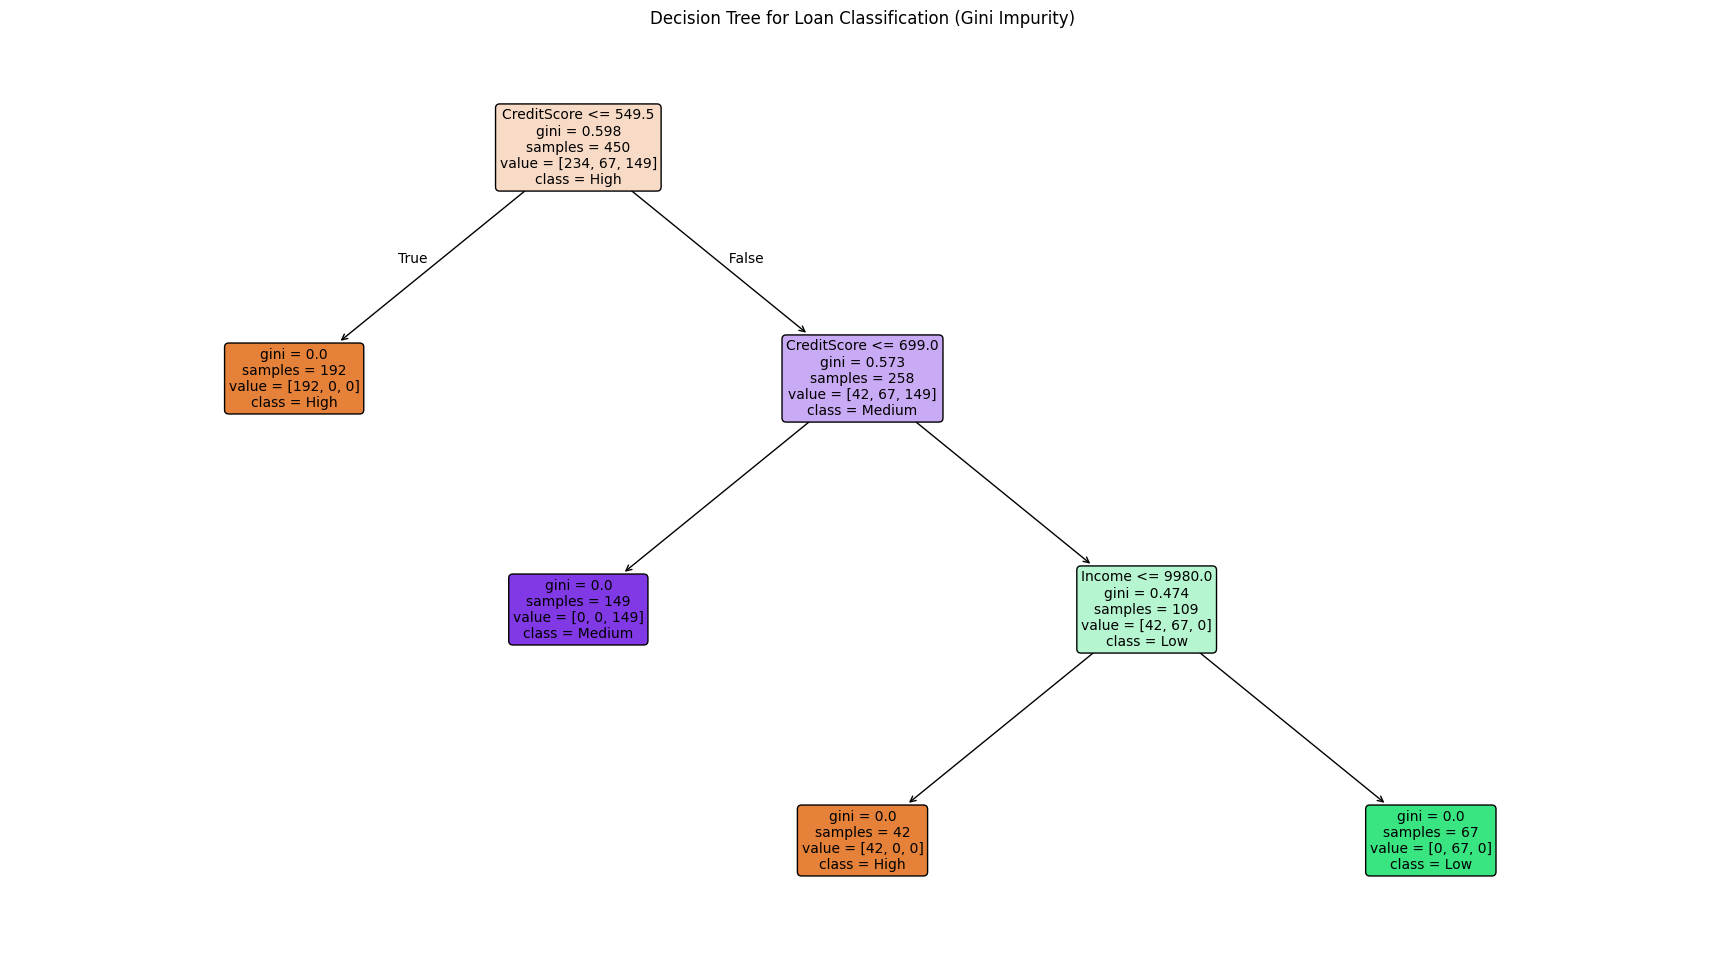

In [31]:
plt.figure(figsize=(22, 12))

plot_tree(
    model_gini,
    feature_names=X.columns,
    class_names=model_gini.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree for Loan Classification (Gini Impurity)")
plt.show()

### Another Model with Entropy as Criterion 

In [37]:
model_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

# Fit model on training data
model_entropy.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

#### Check Evaluation Metrics (again)

In [38]:
# Predict based on test data
y_pred_entropy = model_entropy.predict(X_test)

print("Entropy/Information Gain Model")
print("Accuracy:", accuracy_score(y_test, y_pred_entropy))
print(classification_report(y_test, y_pred_entropy))

Entropy/Information Gain Model
Accuracy: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        88
         Low       1.00      1.00      1.00        17
      Medium       1.00      1.00      1.00        45

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



### Inspect accuracy for values of max_depth between 1 and 6 (Impurity)

In [15]:
train_scores = []
test_scores = []

for depth in range(1, 7):
    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))
    
print(train_scores)
print(test_scores)

[0.7577777777777778, 0.9066666666666666, 1.0, 1.0, 1.0, 1.0]
[0.7866666666666666, 0.9, 1.0, 1.0, 1.0, 1.0]


### Visualise Tree (Entropy)

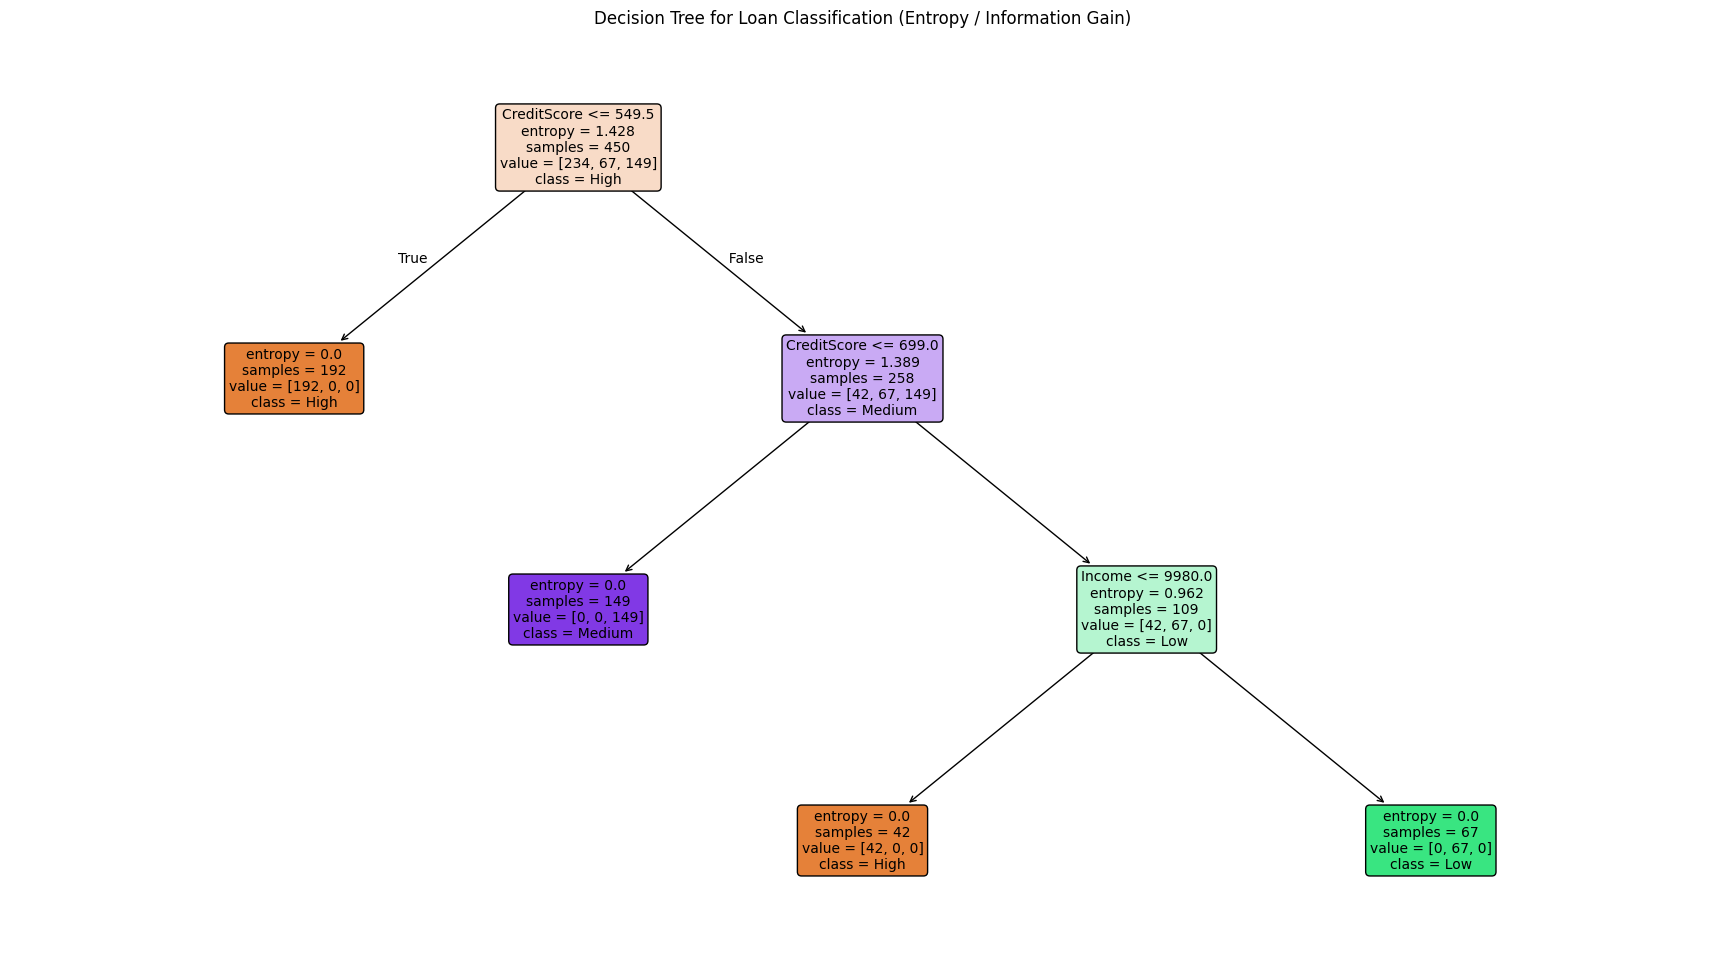

In [ ]:
plt.figure(figsize=(22, 12))

plot_tree(
    model_entropy,
    feature_names = X.columns,
    class_names = model_entropy.classes_,
    filled = True,
    rounded = True,
    fontsize=10
)

plt.title("Decision Tree for Loan Classification (Entropy / Information Gain)")
plt.show()